In [1]:
# ruff: noqa: N803, N806
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from numpy.typing import ArrayLike

## Load and visualize the data

In [2]:
waterquality = pd.read_csv(
    "data/NationalSurveyData.csv",
    sep=",",
    skipinitialspace=True,
    skiprows=(0, 1, 2, 3, 5, 6),
)
# We are only interest in the As column (and lat+lon)
waterquality = waterquality[["SAMPLE_ID", "As", "LAT_DEG", "LONG_DEG"]]
# Convert the Aq values to numeric
waterquality["As"] = waterquality["As"].str.replace(r"^<", "", regex=True).astype(float)
# Convert to a GeoDataFrame
waterquality = gpd.GeoDataFrame(
    waterquality,
    geometry=gpd.points_from_xy(waterquality["LONG_DEG"], waterquality["LAT_DEG"]),
).set_crs(epsg=4326)
# Normalize the geometries and drop duplicate points
waterquality["geometry"] = waterquality.normalize()
waterquality = waterquality.drop_duplicates(subset="geometry")
# Convert to a better fitting crs
waterquality = waterquality.to_crs(epsg=9678)
display(waterquality)
surveyarea = gpd.read_file("data/borders.shp")
surveyarea = surveyarea.to_crs(epsg=9678)
display(surveyarea)

# Plot the survey area
vmax = np.percentile(waterquality["As"], 95)
m = waterquality.explore(column="As", cmap="PiYG_r", tiles="CartoDB positron", vmax=vmax)
surveyarea.boundary.explore(m=m, style_kwds={"fill": False, "color": "black"})
m

,SAMPLE_ID,As,LAT_DEG,LONG_DEG,geometry
0,S98_00718,256.0,23.0194,90.8786,POINT (590312.726 545642.882)
1,S98_00724,38.0,22.9650,90.9597,POINT (598662.875 539672.42)
2,S98_00727,8.0,22.9253,90.9744,POINT (600199.021 535287.188)
3,S98_00733,6.0,22.8653,90.9372,POINT (596426.546 528619.935)
4,S98_00734,6.0,22.8525,90.9058,POINT (593213.879 527182.759)
...,...,...,...,...,...
3528,S99_07379,0.9,24.7733,88.8000,POINT (378965.892 740082.368)
3529,S99_07380,4.7,24.7183,88.7750,POINT (376383.673 734014.059)
3530,S99_07381,0.5,25.1039,88.5713,POINT (356226.902 776918.342)
3531,S99_07382,0.7,25.0296,88.6054,POINT (359580.797 768653.675)


,fid,iso_a2,NAME,FIPS_10_,ISO_A3,WB_A2,WB_A3,geometry
0,1536.0,BD,Bangladesh,BG,BGD,BD,BGD,"MULTIPOLYGON (((568696.59 538181.21, 565209.15..."


## Emprical indicator (Semi-)Variogram

In [3]:
from rich import traceback

traceback.install(show_locals=True)

<bound method InteractiveShell.excepthook of <ipykernel.zmqshell.ZMQInteractiveShell object at 0x79e801ea9c40>>

In [4]:
def empirical_indicator_semivariogram(
    z: gpd.GeoSeries,
    h: ArrayLike | None = None,
    K: list[float] | None = None,
) -> xr.DataArray:
    """Calculate the empirical indicator semivariogram for a given set of thresholds.

    Args:
        z (gpd.GeoSeries): The data to calculate the indicator semivariogram for.
        h (list[float] | None): The bins to calculate the indicator semivariogram for.
            If None, the bins are estimated by linspacing 0 - distances.median() with 40 bins total.
            Defaults to None.
        K (list[float] | None): The thresholds to calculate the indicator semivariogram for.
            If None, the thresholds are estimated by linspacing 0 - z.max() with 10 thresholds total.
            Defaults to None.

    Returns:
        xr.DataArray: The empirical indicator semivariogram.

    """
    # Distance map between each point
    distances = waterquality.geometry.apply(lambda x: x.distance(waterquality.geometry)).to_numpy()
    distances = xr.DataArray(distances, coords={"tail": waterquality.index, "head": waterquality.index}, name="h")
    # Remove upper triangle
    distances = distances.where(np.triu(np.ones(distances.shape), k=1).astype(bool))
    # Remove self-distances
    distances = distances.where(~np.eye(len(waterquality), dtype=bool))

    if h is None:
        h = np.linspace(0, distances.median().item(), 40)
    if K is None:
        K = np.linspace(0, z.max(), 10)

    # Calculate the indicator semivariogram for each threshold
    # Initialize an empty gammas array
    gammas = xr.DataArray(0.0, coords={"threshold": K, "bin": h[:-1]}, dims=["threshold", "bin"])

    # Iterate over the thresholds
    for k in K:
        # Indicator-encode values and calculate the difference between each point
        z_k = (z <= k).astype(int)
        z_k_head = xr.DataArray(z_k, coords={"head": z.index}, name="As").expand_dims({"tail": z.index})
        z_k_tail = xr.DataArray(z_k, coords={"tail": z.index}, name="As").expand_dims({"head": z.index})
        z_k_diff = z_k_head - z_k_tail
        # Iterate over the bins
        for i in range(len(h) - 1):
            # Check which point-pairs are in the distance bin
            is_in_h = (distances > h[i]) & (distances < h[i + 1])
            n_h = is_in_h.sum()  # Number of point-pairs in the bin
            gamma = 1 / (2 * n_h) * (z_k_diff.where(is_in_h) ** 2).sum()
            gammas.loc[{"threshold": k, "bin": h[i]}] = gamma.item()

    return gammas


# h = np.linspace(0, 3, 40)
gammas = empirical_indicator_semivariogram(waterquality["As"], K=[10, 50])
display(gammas)
# gammas.plot.line(x="bin")

<xarray.DataArray (threshold: 2, bin: 39)> Size: 624B
array([[0.1451567 , 0.1447246 , 0.16353339, 0.1723949 , 0.1793052 ,
        0.18421978, 0.19232925, 0.19950885, 0.20173078, 0.20546559,
        0.21096672, 0.21506138, 0.21668435, 0.22149514, 0.22440011,
        0.22591232, 0.22931857, 0.23143088, 0.23197047, 0.23333988,
        0.23375679, 0.23538917, 0.23593822, 0.23573854, 0.23694551,
        0.23879848, 0.23917718, 0.2392423 , 0.23892371, 0.23906577,
        0.23965693, 0.23979661, 0.24148705, 0.24247935, 0.24405012,
        0.24446025, 0.24562985, 0.24407471, 0.24571465],
       [0.10954416, 0.11025307, 0.11938086, 0.12857832, 0.13299091,
        0.13938462, 0.14672764, 0.15180317, 0.15430003, 0.15640017,
        0.15991746, 0.16450946, 0.16409121, 0.16490572, 0.16862745,
        0.17033761, 0.17256474, 0.17751244, 0.17928476, 0.18241728,
        0.18446919, 0.18820726, 0.1881683 , 0.18911595, 0.1913039 ,
        0.19283143, 0.19212576, 0.19225049, 0.19163647, 0.19248645,
        0.1923107 , 0.19424944, 0.19552584, 0.19455443, 0.19712003,
        0.19566954, 0.19595614, 0.19488326, 0.19471037]])
Coordinates:
  * threshold  (threshold) int64 16B 10 50
  * bin        (bin) float64 312B 0.0 4.665e+03 ... 1.726e+05 1.773e+05

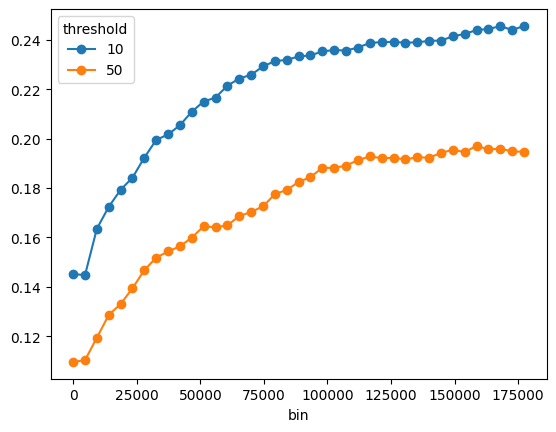

In [5]:
gammas.plot.line(x="bin", marker="o")
plt.show()

## Fit a theoretical indicator (Semi-)Variogram

RANKING by Pseudo-r2 score
     1.          Matern: 0.99584
     2.          Stable: 0.99574
     3.     Exponential: 0.99569
     4.        Rational: 0.99408
     5.  SuperSpherical: 0.98974
     6.       Spherical: 0.97973
     7.        Circular: 0.97513
     8.        Gaussian: 0.96316
     9.         JBessel: 0.96223


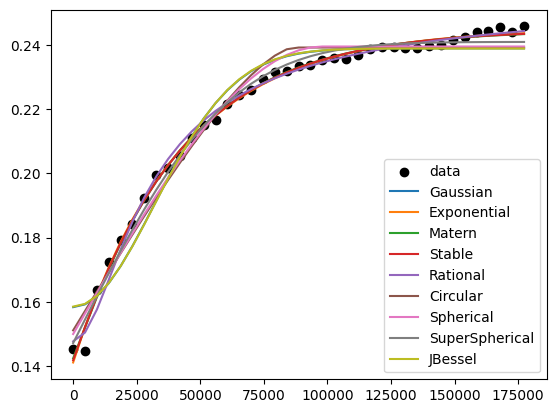

In [6]:
import gstools as gs

models = {
    "Gaussian": gs.Gaussian,
    "Exponential": gs.Exponential,
    "Matern": gs.Matern,
    "Stable": gs.Stable,
    "Rational": gs.Rational,
    "Circular": gs.Circular,
    "Spherical": gs.Spherical,
    "SuperSpherical": gs.SuperSpherical,
    "JBessel": gs.JBessel,
}
scores = {}

# plot the estimated variogram
plt.scatter(gammas.coords["bin"], gammas.sel(threshold=10), color="k", label="data")
ax = plt.gca()

# fit all models to the estimated variogram
for model in models:
    fit_model = models[model](dim=2)
    para, pcov, r2 = fit_model.fit_variogram(gammas.coords["bin"], gammas.sel(threshold=10), return_r2=True)
    y = fit_model.variogram(gammas.coords["bin"])
    ax.plot(gammas.coords["bin"], y, label=model)
    # fit_model.plot(x_max=gammas.coords["bin"].max(), ax=ax)
    scores[model] = r2

ax.legend()

ranking = sorted(scores.items(), key=lambda item: item[1], reverse=True)
print("RANKING by Pseudo-r2 score")
for i, (model, score) in enumerate(ranking, 1):
    print(f"{i:>6}. {model:>15}: {score:.5}")

RANKING by Pseudo-r2 score
     1.          Matern: 0.99309
     2.          Stable: 0.99308
     3.     Exponential: 0.99304
     4.  SuperSpherical: 0.9899
     5.        Rational: 0.98783
     6.       Spherical: 0.9843
     7.        Circular: 0.98055
     8.        Gaussian: 0.96108
     9.         JBessel: 0.96027


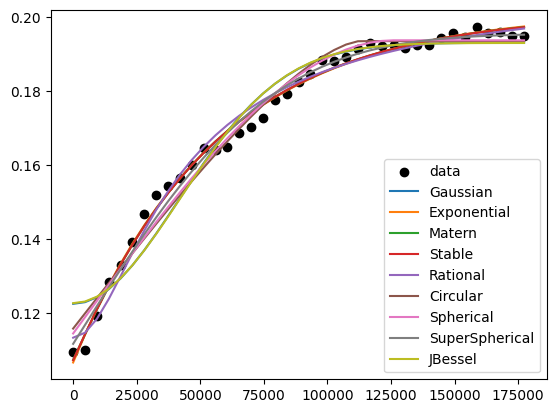

In [7]:
scores = {}

# plot the estimated variogram
plt.scatter(gammas.coords["bin"], gammas.sel(threshold=50), color="k", label="data")
ax = plt.gca()

# fit all models to the estimated variogram
for model in models:
    fit_model = models[model](dim=2)
    para, pcov, r2 = fit_model.fit_variogram(gammas.coords["bin"], gammas.sel(threshold=50), return_r2=True)
    y = fit_model.variogram(gammas.coords["bin"])
    ax.plot(gammas.coords["bin"], y, label=model)
    # fit_model.plot(x_max=gammas.coords["bin"].max(), ax=ax)
    scores[model] = r2

ax.legend()

ranking = sorted(scores.items(), key=lambda item: item[1], reverse=True)
print("RANKING by Pseudo-r2 score")
for i, (model, score) in enumerate(ranking, 1):
    print(f"{i:>6}. {model:>15}: {score:.5}")

In [8]:
# Matern seems to fit best
models = {}
for threshold in gammas.coords["threshold"]:
    fit_model = gs.Matern(dim=2)
    para, pcov, r2 = fit_model.fit_variogram(gammas.coords["bin"], gammas.sel(threshold=threshold), return_r2=True)
    models[threshold.item()] = fit_model
models

{10: Matern(dim=2, var=0.102, len_scale=2.88e+04, nugget=0.142, nu=0.545),
 50: Matern(dim=2, var=0.0934, len_scale=3.91e+04, nugget=0.107, nu=0.528)}

In [ ]:
r

In [81]:
import rpy2.robjects as robjects
import rpy2.robjects as robjects
import rpy2.robjects.packages as rpackages
from rpy2.robjects import pandas2ri

pandas2ri.activate()

# Load required R packages
gstat = rpackages.importr("gstat")
sp = rpackages.importr("sp")
sf = rpackages.importr("sf")

r_code = """
function(gdf, grid_sf, model, nmax, nsim) {
  library(gstat)
  library(sp)
  library(sf)

  # Ensure LAT_DEG and LONG_DEG columns exist
  if (!("LAT_DEG" %in% colnames(gdf)) | !("LONG_DEG" %in% colnames(gdf))) {
    stop("Error: LAT_DEG and LONG_DEG columns missing in gdf.")
  }
  if (!("LAT_DEG" %in% colnames(grid_sf)) | !("LONG_DEG" %in% colnames(grid_sf))) {
    stop("Error: LAT_DEG and LONG_DEG columns missing in grid_sf.")
  }

  # Convert DataFrame to sf object
  gdf <- st_as_sf(gdf, coords = c("LONG_DEG", "LAT_DEG"), crs = 4326)
  grid_sf <- st_as_sf(grid_sf, coords = c("LONG_DEG", "LAT_DEG"), crs = 4326)

  # Perform Kriging using only the 'As_IK_10' variable
  k_sim <- krige(formula = As ~ 1, locations = gdf, 
                 newdata = grid_sf, model = model, 
                 nmax = nmax, nsim = nsim, indicators=TRUE)
  print(k_sim)
  k_sim_df <- as.data.frame(k_sim)

  return(k_sim)
}
"""

# Convert Python function to an R function
krige_r = robjects.r(r_code)

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  library ‘/usr/local/lib/R/site-library’ contains no packages

R[write to console]: 2: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  library ‘/usr/local/lib/R/site-library’ contains no packages

R[write to console]: 3: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  library ‘/usr/local/lib/R/site-library’ contains no packages



In [82]:
def convert_matern_dict(matern_dict):
    r_variograms = {}

    for key, matern in matern_dict.items():
        # Extract parameters
        psill = matern.var       # Partial sill (variance)
        len_scale = matern.len_scale  # Range (length scale)
        nugget = matern.nugget   # Nugget effect
        nu = matern.nu           # Smoothness (kappa in R)

        # Define R variogram object
        r_code = f"""
        library(gstat)
        mdl_v_fit_{key} <- vgm(psill = {psill}, model = "Mat", range = {len_scale}, 
                               nugget = {nugget}, kappa = {nu})
        assign("mdl_v_fit_{key}", mdl_v_fit_{key}, envir = .GlobalEnv)
        print(mdl_v_fit_{key})
        """
        robjects.r(r_code)
        r_variograms[key] = robjects.r[f'mdl_v_fit_{key}']

    return r_variograms

In [83]:
r_variograms=convert_matern_dict(models)

  model     psill    range     kappa
   Nug 0.1423819     0.00 0.0000000
   Mat 0.1021874 28802.81 0.5454251
  model      psill    range     kappa
   Nug 0.10749967     0.00 0.0000000
   Mat 0.09342792 39115.22 0.5278251


In [84]:
r_variograms[10]

model,psill,range,...,ang3,anis1,anis2
Nug,...,...,...,...,...,...
Mat,,,,,,


In [85]:
gdf=waterquality
n_points = 100
xy = np.meshgrid(
    np.linspace(gdf.total_bounds[0], gdf.total_bounds[2], n_points),
    np.linspace(gdf.total_bounds[1], gdf.total_bounds[3], n_points),

)
grid_gdf = gpd.GeoDataFrame(
    {'LONG_DEG': xy[0].ravel(), 'LAT_DEG': xy[1].ravel()}, 
    geometry=gpd.points_from_xy(xy[0].ravel(), xy[1].ravel()), 
    crs=gdf.crs
)

# Convert to Pandas DataFrame before passing to R
gdf = gdf.drop(columns=['geometry'])  # Ensure LAT_DEG and LONG_DEG exist
grid_df = grid_gdf.drop(columns=['geometry'])

# Convert GeoPandas DataFrame to R dataframe
r_gdf = pandas2ri.py2rpy(gdf)
r_grid_df = pandas2ri.py2rpy(grid_df)

In [86]:
kriging_result = krige_r(r_gdf, r_grid_df, r_variograms[10], 50, 100)

drawing 100 GLS realisations of beta...
[using conditional indicator simulation]
Simple feature collection with 10000 features and 100 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 306464.1 ymin: 298033.9 xmax: 751312.2 ymax: 946489.9
Geodetic CRS:  WGS 84
First 10 features:
   sim1 sim2 sim3 sim4 sim5 sim6 sim7 sim8 sim9 sim10 sim11 sim12 sim13 sim14
    1    1    1    1    1    1    1    1    1     1     1     1     1     1
    1    1    1    1    1    1    1    1    1     1     1     1     1     1
    1    1    1    1    1    1    1    1    1     1     1     1     1     1
    1    1    1    1    1    1    1    1    1     1     1     1     1     1
    1    1    1    1    1    1    1    1    1     1     1     1     1     1
    1    1    1    1    1    1    1    1    1     1     1     1     1     1
    1    1    1    1    1    1    1    1    1     1     1     1     1     1
    1    1    1    1    1    1    1    1    1     1     1     1     1     1
    1    1    1  

In [80]:
kriging_df = pandas2ri.rpy2py(kriging_result)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 kriging_df = pandas2ri.rpy2py(kriging_result)                                                │
│   2                                                                                              │
│                                                                                                  │
│ ╭─────────────────────────────────────────── locals ───────────────────────────────────────────╮ │
│ │      ArrayLike = typing.Union[collections.abc.Buffer,                                        │ │
│ │                  numpy._typing._array_like._SupportsArray[numpy.dtype[typing.Any]],          │ │
│ │                  numpy._typing._nested_sequence._NestedSequence[numpy._typing._array_like._… │ │
│ │                  bool, int, float, complex, str, bytes,                                      │ │
│ │                  numpy._typing._nested_sequence._NestedSequence[bool | int | float | complex │ │
│ │                  | str | bytes]]                                                             │ │
│ │             ax = <Axes: >                                                                    │ │
│ │           exit = <IPython.core.autocall.ZMQExitAutocall object at 0x79e8001595e0>            │ │
│ │      fit_model = Matern(dim=2, var=0.0934, len_scale=3.91e+04, nugget=0.107, nu=0.528)       │ │
│ │         gammas = <xarray.DataArray (threshold: 2, bin: 39)> Size: 624B                       │ │
│ │                  array([[0.1451567 , 0.1447246 , 0.16353339, 0.1723949 , 0.1793052 ,         │ │
│ │                  │   │   0.18421978, 0.19232925, 0.19950885, 0.20173078, 0.20546559,         │ │
│ │                  │   │   0.21096672, 0.21506138, 0.21668435, 0.22149514, 0.22440011,         │ │
│ │                  │   │   0.22591232, 0.22931857, 0.23143088, 0.23197047, 0.23333988,         │ │
│ │                  │   │   0.23375679, 0.23538917, 0.23593822, 0.23573854, 0.23694551,         │ │
│ │                  │   │   0.23879848, 0.23917718, 0.2392423 , 0.23892371, 0.23906577,         │ │
│ │                  │   │   0.23965693, 0.23979661, 0.24148705, 0.24247935, 0.24405012,         │ │
│ │                  │   │   0.24446025, 0.24562985, 0.24407471, 0.24571465],                    │ │
│ │                  │      [0.10954416, 0.11025307, 0.11938086, 0.12857832, 0.13299091,         │ │
│ │                  │   │   0.13938462, 0.14672764, 0.15180317, 0.15430003, 0.15640017,         │ │
│ │                  │   │   0.15991746, 0.16450946, 0.16409121, 0.16490572, 0.16862745,         │ │
│ │                  │   │   0.17033761, 0.17256474, 0.17751244, 0.17928476, 0.18241728,         │ │
│ │                  │   │   0.18446919, 0.18820726, 0.1881683 , 0.18911595, 0.1913039 ,         │ │
│ │                  │   │   0.19283143, 0.19212576, 0.19225049, 0.19163647, 0.19248645,         │ │
│ │                  │   │   0.1923107 , 0.19424944, 0.19552584, 0.19455443, 0.19712003,         │ │
│ │                  │   │   0.19566954, 0.19595614, 0.19488326, 0.19471037]])                   │ │
│ │                  Coordinates:                                                                │ │
│ │                    * threshold  (threshold) int64 16B 10 50                                  │ │
│ │                    * bin        (bin) float64 312B 0.0 4.665e+03 ... 1.726e+05 1.773e+05     │ │
│ │            gdf = │     SAMPLE_ID     As  LAT_DEG  LONG_DEG                                   │ │
│ │                  0     S98_00718  256.0  23.0194   90.8786                                   │ │
│ │                  1     S98_00724   38.0  22.9650   90.9597                                   │ │
│ │                  2     S98_00727    8.0  22.9253   90.974